# Tables 5 & 6 — Workload Taxonomy and Operator Structure

Companion to [`table_1.ipynb`](table_1.ipynb) and [`tables_2_3_4.ipynb`](tables_2_3_4.ipynb); same
reference workloads, `PRETTY`/`COL`/`show()` conventions, and the same `to_latex` layout as Tables 1–4
(one row per workload, one column per metric, two-line `makecell` headers, `\resizebox`).

Two tables, one question each:

| Table | Question | Columns |
|---|---|---|
| **5 · Workload taxonomy** | *How do the workloads behave when executed?* | pure runtime: the per-query runtime distribution as min / mean / median / P90 / max (the per-bucket counts are left to the runtime-distribution figure) |
| **6 · Query text and operator structure** | *What do the queries look like?* | text length; mean per-query TableScan, Join, Sort, GroupBy, Select, Window, Nesting |

SQLStorm's Table 5 is the model for the operator rows. **Method**: static analysis of the SQL
text via `workload_generation/shared/sql_features.py` (`query_features`, sqlglot-backed) over
`Workloads/<name>/q*.sql` — no Trino needed — plus raw `runtime_s` from the lakehouse execution traces
(the same loader as `workload_runtime_distributions.ipynb`) for the runtime columns.

**Adaptations from SQLStorm's rows**: *TableScan* = tables referenced per query; *Select* = predicates per
query; *Nesting* = subqueries + CTEs.

`to_latex` deviates from the reference in one way: an optional `no_bold=` kwarg, used to switch off
best-in-column bold/underline: both tables here are descriptive, so neither highlights a winner.

## 0 · Setup

In [1]:
import json, re, glob, math
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
ROOT = Path("/mnt/primary/Main")
for _p in (str(Path.cwd()), str(ROOT)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loader.stats import load_sql_workload
from workload_generation.shared.sql_features import (
    query_features, _tokens, _STRING_HINT, _REGEX_HINT, _JSON_HINT,
)

WORKLOAD_ROOT = ROOT / "Workloads"
RESULTS_DIR = Path("./results").resolve()
FIGURES_DIR = Path("./results/figures").resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Same reference set / order / naming as tables_2_3_4.ipynb.
REF       = "tpcds_1000"
OURS      = ["gpt_generated_1000_tpcds_tokens_no_feedback", "gpt_generated_1000_tpcds_tokens"]
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
             "e2etune_1000_tokens_tpcds",
             "sql_factory_1000_tokens_tpcds",
             "sqlbarber_1000_tokens_tpcds",
             "sqlstorm_1000_tokens_tpcds"]
ROWS = [REF] + BASELINES + OURS   # reference first, baselines (A-Z), ours last

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

PRETTY = {"tpcds_1000":"TPC-DS (1000)", "gpt_generated_1000_tpcds_tokens":"DiverSQL (W/ Feedback)", "gpt_generated_1000_tpcds_tokens_no_feedback":"DiverSQL (W/O Feedback)",
          "sqlstorm_1000_tokens_tpcds":"SQLStorm", "sqlbarber_1000_tokens_tpcds":"SQLBarber",
          "sql_factory_1000_tokens_tpcds":"SQL-Factory", "e2etune_1000_tokens_tpcds":"E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds":"Bootstrapping-LCM"}

COL = {w: "#b8b8b8" for w in ROWS}
for w in OURS: COL[w] = "#ea580c"
COL[REF] = "#111111"
_INV = {v:k for k,v in PRETTY.items()}

def show(tbl, fmt="{:.3f}", **kw):
    disp = tbl.rename(index=PRETTY)
    def hl(row):
        key = _INV.get(row.name, row.name)
        if key == REF:  return ["background-color:#f3f4f6;font-style:italic"]*len(row)
        if key in OURS: return ["background-color:#fff1e6;font-weight:600"]*len(row)
        return [""]*len(row)
    sty = disp.style.apply(hl, axis=1)
    return sty.format(fmt, **kw) if fmt else sty


## 1 · Expression sub-categories

`sql_features.py` defines `_STRING_HINT` / `_REGEX_HINT` / `_JSON_HINT` for its complexity bucketing but only
exposes their union (`num_functions`). Re-split the *same* sets into SQLStorm's expression categories; `like`
and `regexp_like` are pulled into a separate *string matching* bucket since SQLStorm reports matching and
regex as distinct columns.

In [2]:
STRING_MOD   = _STRING_HINT - {"like"}
STRING_MATCH = {"like", "ilike", "regexp_like"}
REGEX_FN     = (_REGEX_HINT - {"regexp_like"}) | {"regexp_split"}
JSON_FN      = set(_JSON_HINT)

print("string modification:", sorted(STRING_MOD))
print("string matching:    ", sorted(STRING_MATCH))
print("regex:              ", sorted(REGEX_FN))
print("json:               ", sorted(JSON_FN))

def expression_counts(sql: str) -> dict:
    tc = Counter(_tokens(sql))
    return {
        "string_modification": sum(tc[t] for t in STRING_MOD),
        "string_matching":     sum(tc[t] for t in STRING_MATCH),
        "regex":               sum(tc[t] for t in REGEX_FN),
        "json":                sum(tc[t] for t in JSON_FN),
        "unnest":              tc["unnest"],
    }


string modification: ['concat', 'length', 'lower', 'position', 'replace', 'split', 'substr', 'substring', 'trim', 'upper']
string matching:     ['ilike', 'like', 'regexp_like']
regex:               ['regexp_extract', 'regexp_replace', 'regexp_split']
json:                ['json_array', 'json_extract', 'json_format', 'json_object', 'json_parse', 'json_query', 'json_value']


## 2 · Per-query static features for every workload

`query_features` (sqlglot, regex fallback) + `expression_counts`. The parse rate is reported per workload: a
query that fails to parse falls back to the cruder regex tokeniser and under-counts joins/predicates.

In [ ]:
per_query_by_workload = {}
parse_stats = []

for w in ROWS:
    wl = load_sql_workload(WORKLOAD_ROOT / w)
    rows = []
    n_parsed = 0
    for qname, rec in wl["queries"].items():
        sql = rec["sql"]
        feat = query_features(sql)
        feat.update(expression_counts(sql))
        feat["nesting"] = feat["num_subqueries"] + feat["num_ctes"]
        rows.append(feat)
        n_parsed += int(feat["parsed"])
    per_query_by_workload[w] = rows
    parse_stats.append({"workload": w, "n_queries": len(rows),
                        "sqlglot_parsed": n_parsed, "parse_rate": n_parsed / len(rows) if rows else float("nan")})

df_parse = pd.DataFrame(parse_stats).set_index("workload")
display(show(df_parse, None).format({"parse_rate": "{:.1%}"}))


## 3 · Runtime distributions (per-query `runtime_s` from the execution traces)

Same loader and run ids as `workload_runtime_distributions.ipynb` (`load_aligned_plans_and_runs`,
`use_scalar_runtime=True`). Lenient by design: a workload whose run is missing or unreadable (e.g. a
mount-permission error) gets `NaN` runtime cells (rendered `--`) instead of failing the notebook.

In [ ]:
from uncertainty_prediction.new_config import PARSED_RESULTS_ROOT, METRIC, XCOL, YCOL
from uncertainty_prediction.src import canon_qid
from loader.load import load_aligned_plans_and_runs

SCHEMA_NAME, LAKEHOUSE_INSTANCE_NAME = "tpcds", "lakehouse-h"

# workload key -> (collection, run_id) of its execution run; None = never executed.
# Mirrors workload_runtime_distributions.ipynb's LEGS (kept in sync by hand).
RUNTIME_RUNS = {
    "tpcds_1000":                                   ("tpcds_1200", "20260816-120034Z"),   # see caveat above
    "bootstrapping_lcm_1000_tokens_tpcds":          ("bootstrapping_lcm_1000_tokens_tpcds", "20260816-171633Z"),
    "e2etune_1000_tokens_tpcds":                    ("e2etune_1000_tokens_tpcds", "20260817-044319Z"),
    "sql_factory_1000_tokens_tpcds":                ("sql_factory_1000_tokens_tpcds", "20260817-133213Z"),
    "sqlbarber_1000_tokens_tpcds":                  ("sqlbarber_1000_tokens_tpcds", "20260818-033107Z"),
    "sqlstorm_1000_tokens_tpcds":                   ("sqlstorm_1000_tokens_tpcds_new", "20260819-161625Z"),
    "gpt_generated_1000_tpcds_tokens":              ("gpt_generated_1000_tpcds_tokens", "20260813-214605Z"),
    "gpt_generated_1000_tpcds_tokens_no_feedback":  ("gpt_generated_1000_tpcds_tokens_no_feedback", "20260921-111847Z"),
}

# Clip runs with more than 1000 queries to q1..q1000 so every workload gets the same 1000-query budget.
MAX_QID = {"tpcds_1000": 1000}

RUNTIMES = {}
DATA_ROOTS = [
    "/mnt/lakehouse-raw-results",
    "/mnt/lakehouse-raw-results-2",   # not mounted on every pod -- see notes below if a run "disappears"
]

for w in ROWS:
    spec = RUNTIME_RUNS.get(w)
    if spec is None:
        print(f"[no run] {PRETTY[w]}: never executed -- runtime cells will be --")
        continue
    collection, run_id = spec

    runs_by_query = common = None
    last_exc = None
    misses = []
    for root in DATA_ROOTS:
        queries_dir = Path(root) / SCHEMA_NAME / LAKEHOUSE_INSTANCE_NAME / run_id / "queries"
        if not queries_dir.is_dir():
            misses.append(f"{root}: not found (root unmounted here, or run's raw output lives elsewhere)")
            continue
        try:
            _, runs_by_query, common = load_aligned_plans_and_runs(
                queries_dir=queries_dir,
                run_ids=[run_id], collection=collection, schema=SCHEMA_NAME, instance=LAKEHOUSE_INSTANCE_NAME,
                metric=METRIC, xcol=XCOL, ycol=YCOL, parsed_results_root=PARSED_RESULTS_ROOT,
                canon_fn=canon_qid, use_scalar_runtime=True,
            )
            break  # got it, stop trying other roots
        except Exception as e:
            last_exc = e
            misses.append(f"{root}: {type(e).__name__}: {e}")

    if runs_by_query is None:
        reason = "; ".join(misses) if misses else (f"{type(last_exc).__name__}: {last_exc}" if last_exc else "unknown")
        print(f"[failed] {PRETTY[w]}: {reason} -- runtime cells will be --")
        continue

    if not common:
        print(f"[empty] {PRETTY[w]}: run dir found but no plans matched runtimes.csv -- runtime cells will be --")
        continue

    if w in MAX_QID:
        n_before = len(common)
        common = [q for q in common if int(q.lstrip("q")) <= MAX_QID[w]]
        print(f"[clip] {PRETTY[w]}: kept q1..q{MAX_QID[w]} ({n_before} -> {len(common)} queries)")

    RUNTIMES[w] = np.array([df["runtime_s"].iloc[0] for q in common for df in runs_by_query[q]], dtype=float)
    print(f"{PRETTY[w]:26s} {len(RUNTIMES[w]):5d} executed runs")


## 4 · Candidate columns, then the explicit drop list

Every candidate metric first, then an **explicit** drop list with a reason per column, asserted against the
data so a dropped column that starts carrying signal fails loudly instead of being silently hidden.

Dropped so far (cumulative): `Query count`, `Length (chars), median`, `Length (tokens), mean`,
`Iteration (recursive) %`, `JSON`, `Complexity low %`, `Complexity medium %`, `Complexity high %`, `ArrayUnnest`,
`SetOperation`, `String modif.`, `String match.`, `Regex`, `Executed (n)`, and the five runtime-bucket counts
(`Runtime <100 ms` … `Runtime >=1 min`). Add further drops to `DROPPED`
below (one line each) — the two tables are built from the `TAXONOMY_COLS` / `STRUCTURE_COLS` lists, so a
column that should go is removed from its list and recorded here.

In [ ]:
def _mean(rows, key):
    vals = [r.get(key, 0) or 0 for r in rows]
    return float(np.mean(vals)) if vals else float("nan")

def _median(rows, key):
    vals = [r.get(key, 0) or 0 for r in rows]
    return float(np.median(vals)) if vals else float("nan")

def _share(rows, tier):
    return 100 * sum(r["complexity"] == tier for r in rows) / len(rows)

def _rt(w, fn):
    v = RUNTIMES.get(w)
    return float(fn(v)) if v is not None and len(v) else float("nan")

CANDIDATES = {   # column label -> aggregator(workload key)
    "Query count":            lambda w: float(len(per_query_by_workload[w])),
    "Length (chars), mean":   lambda w: _mean(per_query_by_workload[w], "query_length_chars"),
    "Length (chars), median": lambda w: _median(per_query_by_workload[w], "query_length_chars"),
    "Length (tokens), mean":  lambda w: _mean(per_query_by_workload[w], "query_length_tokens"),
    "TableScan":              lambda w: _mean(per_query_by_workload[w], "num_tables"),
    "Join":                   lambda w: _mean(per_query_by_workload[w], "num_joins"),
    "Sort":                   lambda w: _mean(per_query_by_workload[w], "num_order_by"),
    "GroupBy":                lambda w: _mean(per_query_by_workload[w], "num_group_by"),
    "Select":                 lambda w: _mean(per_query_by_workload[w], "num_predicates"),
    "Window":                 lambda w: _mean(per_query_by_workload[w], "num_window_functions"),
    "SetOperation":           lambda w: _mean(per_query_by_workload[w], "num_set_operations"),
    "ArrayUnnest":            lambda w: _mean(per_query_by_workload[w], "unnest"),
    "Nesting":                lambda w: _mean(per_query_by_workload[w], "nesting"),
    "Iteration (recursive), %": lambda w: 100 * _mean(per_query_by_workload[w], "recursive"),
    "String modif.":          lambda w: _mean(per_query_by_workload[w], "string_modification"),
    "String match.":          lambda w: _mean(per_query_by_workload[w], "string_matching"),
    "Regex":                  lambda w: _mean(per_query_by_workload[w], "regex"),
    "JSON":                   lambda w: _mean(per_query_by_workload[w], "json"),
    "Complexity low, %":      lambda w: _share(per_query_by_workload[w], "low"),
    "Complexity medium, %":   lambda w: _share(per_query_by_workload[w], "medium"),
    "Complexity high, %":     lambda w: _share(per_query_by_workload[w], "high"),
    "Runtime min (s)":        lambda w: _rt(w, np.min),
    "Runtime mean (s)":       lambda w: _rt(w, np.mean),
    "Runtime median (s)":     lambda w: _rt(w, np.median),
    "Runtime P90 (s)":        lambda w: _rt(w, lambda v: np.percentile(v, 90)),
    "Runtime max (s)":        lambda w: _rt(w, np.max),
    "Executed (n)":           lambda w: _rt(w, len),
    "Runtime <100 ms":        lambda w: _rt(w, lambda v: (v < 0.1).sum()),
    "Runtime 100 ms-1 s":     lambda w: _rt(w, lambda v: ((v >= 0.1) & (v < 1)).sum()),
    "Runtime 1-10 s":         lambda w: _rt(w, lambda v: ((v >= 1) & (v < 10)).sum()),
    "Runtime 10 s-1 min":     lambda w: _rt(w, lambda v: ((v >= 10) & (v < 60)).sum()),
    "Runtime >=1 min":        lambda w: _rt(w, lambda v: (v >= 60).sum()),
}

taxonomy_full = pd.DataFrame(
    {label: [fn(w) for w in ROWS] for label, fn in CANDIDATES.items()}, index=ROWS,
).astype(float)

DROPPED = {
    "Query count":              "dataset size (~1000 for all), not a taxonomy property",
    "Length (chars), median":   "redundant with the mean",
    "Length (tokens), mean":    "redundant with chars (near-perfectly correlated)",
    "Iteration (recursive), %": "~0 everywhere: Trino has no recursive CTEs",
    "JSON":                     "0 for every workload: no generator emits JSON functions",
    "Complexity low, %":        "complexity tiers not reported; Table 6 is operator structure only",
    "Complexity medium, %":     "see above",
    "Complexity high, %":       "see above",
    "String modif.":            "expression usage not reported; Table 6 is operator structure only",
    "String match.":            "see above",
    "Regex":                    "see above",
    "Executed (n)":             "executed count is validity (Table 3), not runtime behaviour",
    **{b: "binned counts are shown by the runtime-distribution figure; Table 5 gives summary stats instead"
       for b in ["Runtime <100 ms", "Runtime 100 ms-1 s", "Runtime 1-10 s", "Runtime 10 s-1 min", "Runtime >=1 min"]},
    "ArrayUnnest": "",
    "SetOperation": "",
}
assert taxonomy_full["JSON"].max() == 0, "JSON is no longer all-zero -- keep this column"
assert taxonomy_full["Iteration (recursive), %"].max() <= 0.5, "recursive queries are no longer negligible -- keep this column"

print("dropped columns:")
for k, why in DROPPED.items():
    print(f"  - {k:26s} {why}")

# ---- Table 5: workload taxonomy   /   Table 6: operator structure -----------------
# Table 5 = pure runtime info: summary stats of the per-query runtime distribution. The bucket counts
# (edges 100 ms / 1 s / 10 s / 1 min, matching the runtime-distribution figure) are computed but dropped.
RUNTIME_BUCKETS = ["Runtime <100 ms", "Runtime 100 ms-1 s", "Runtime 1-10 s", "Runtime 10 s-1 min", "Runtime >=1 min"]
TAXONOMY_COLS = ["Runtime min (s)", "Runtime mean (s)", "Runtime median (s)", "Runtime P90 (s)", "Runtime max (s)"]
# Table 6 = static structure of the SQL text: length and per-query operator counts.
STRUCTURE_COLS = ["Length (chars), mean",
                  "TableScan", "Join", "Sort", "GroupBy", "Select", "Window", "Nesting"]

_used = set(TAXONOMY_COLS) | set(STRUCTURE_COLS)
assert not (_used & set(DROPPED)), f"a dropped column is still in a table: {_used & set(DROPPED)}"
assert set(taxonomy_full.columns) - _used == set(DROPPED), (
    "every candidate must be either in a table or in DROPPED: "
    f"{set(taxonomy_full.columns) - _used - set(DROPPED)}")

table5 = taxonomy_full[TAXONOMY_COLS]
table6 = taxonomy_full[STRUCTURE_COLS].rename(columns={"Length (chars), mean": "Length (chars)"})
table5.to_csv(RESULTS_DIR / "table5_workload_taxonomy.csv")
table6.to_csv(RESULTS_DIR / "table6_operator_structure.csv")

FMTS5 = {"Runtime min (s)": "{:.3f}", "Runtime mean (s)": "{:.2f}", "Runtime median (s)": "{:.2f}",
         "Runtime P90 (s)": "{:.2f}", "Runtime max (s)": "{:.1f}"}
FMTS6 = {"Length (chars)": "{:.0f}",
         "TableScan": "{:.2f}", "Join": "{:.2f}", "Sort": "{:.2f}", "GroupBy": "{:.2f}", "Select": "{:.2f}",
         "Window": "{:.3f}", "Nesting": "{:.2f}"}
assert list(FMTS5) == list(table5.columns), (list(FMTS5), list(table5.columns))
assert list(FMTS6) == list(table6.columns), (list(FMTS6), list(table6.columns))
_bsum = taxonomy_full[RUNTIME_BUCKETS].sum(axis=1, min_count=1)
assert ((_bsum - taxonomy_full["Executed (n)"]).abs().fillna(0) < 1e-9).all(), "runtime buckets must partition the executed queries"


dropped columns:
  - Query count                dataset size (~1000 for all), not a taxonomy property
  - Length (chars), median     redundant with the mean
  - Length (tokens), mean      redundant with chars (near-perfectly correlated)
  - Iteration (recursive), %   ~0 everywhere: Trino has no recursive CTEs
  - JSON                       0 for every workload: no generator emits JSON functions
  - Complexity low, %          three tier shares sum to 100; 'high' alone carries the signal
  - Complexity medium, %       see above


### Table 5 — Workload taxonomy (runtime distribution)

In [13]:
show(table5, None).format(FMTS5, na_rep="—")

,Executed (n),Runtime median (s),Runtime P90 (s),Runtime max (s),Runtime <100 ms,Runtime 100 ms-1 s,Runtime 1-10 s,Runtime 10 s-1 min,Runtime >=1 min
TPC-DS (1000),1208,1.07,6.05,91.4,0,588,569,41,10
Bootstrapping-LCM,971,0.48,2.41,1025.2,0,773,164,22,12
E2ETune,989,0.30,2.92,1624.3,51,680,234,18,6
SQL-Factory,972,2.88,18.77,871.6,0,236,532,176,28
SQLBarber,982,0.31,2.30,62.3,86,715,151,29,1
SQLStorm,922,4.55,29.85,1675.8,1,179,464,237,41
DiverSQL (W/O Feedback),970,0.90,8.20,1513.5,26,492,385,51,16
DiverSQL (W/ Feedback),949,1.16,9.08,1418.1,16,418,433,65,17


### Table 6 — Query text and operator structure

In [14]:
show(table6, None).format(FMTS6, na_rep="—")

,Length (chars),TableScan,Join,Sort,GroupBy,Select,Window,SetOperation,ArrayUnnest,Nesting,String modif.,String match.,Regex,High complexity %
TPC-DS (1000),1569,5.74,5.65,1.08,1.45,15.95,0.276,0.464,0.000,2.37,0.247,0.007,0.000,14.6
Bootstrapping-LCM,1603,5.34,6.26,1.29,1.12,9.47,0.332,0.000,0.000,0.52,0.031,0.006,0.000,11.0
E2ETune,1363,5.34,3.56,1.81,1.53,8.86,0.824,0.070,0.000,1.67,0.020,0.043,0.000,3.4
SQL-Factory,1353,5.57,3.10,2.77,1.46,6.65,1.937,0.105,0.001,2.09,0.013,0.019,0.000,0.2
SQLBarber,484,2.76,1.75,0.12,0.77,4.58,0.012,0.000,0.000,0.25,0.120,0.000,0.000,0.0
SQLStorm,2643,9.56,6.12,2.03,2.04,12.09,1.151,1.656,0.012,4.07,1.968,0.168,0.473,36.1
DiverSQL (W/O Feedback),1853,9.04,7.92,1.48,1.32,14.73,0.558,0.478,0.071,2.68,0.250,0.477,0.168,54.6
DiverSQL (W/ Feedback),2319,10.40,8.56,1.49,1.32,17.30,0.578,1.040,0.112,4.75,0.241,0.510,0.122,57.8


## 5 · Visual check — runtime distribution

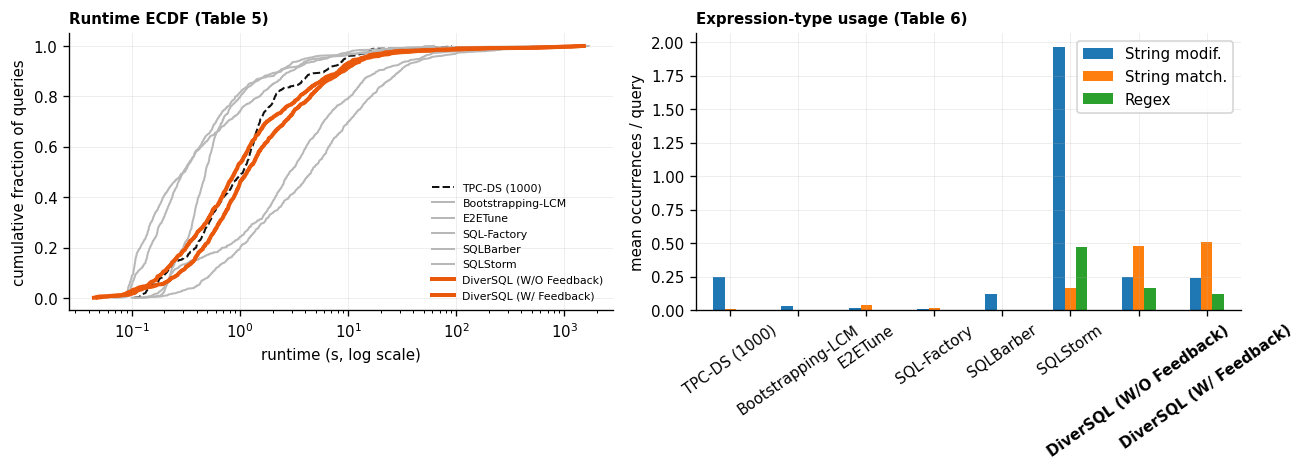

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 4.0))

# runtime distribution (log-x ECDF) -- sanity check for the Table 5 runtime columns
for w in ROWS:
    v = RUNTIMES.get(w)
    if v is None:
        continue
    v = np.sort(v)
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=COL[w],
            lw=2.4 if w in OURS else 1.2, ls="--" if w == REF else "-", label=PRETTY[w])
ax.set_xscale("log"); ax.set_xlabel("runtime (s, log scale)"); ax.set_ylabel("cumulative fraction of queries")
ax.set_title("Runtime ECDF (Table 5)", loc="left", fontsize=9, fontweight="bold")
ax.legend(fontsize=6.5, frameon=False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "table5_runtime_and_expressions.png")
fig.savefig(FIGURES_DIR / "table5_runtime_and_expressions.pdf")
plt.show()


## 6 · LaTeX export

`_tex_escape` / `_tex_header` / `to_latex` are copied from `tables_2_3_4.ipynb` §5 (plus the `no_bold` kwarg
noted at the top), so both tables are formatted like Tables 1–4. Requires `booktabs`, `graphicx`, `makecell`.

In [16]:
_LATEX_SPECIAL = {"%": r"\%", "&": r"\&", "_": r"\_", "#": r"\#"}
def _tex_escape(s):
    for ch, esc in _LATEX_SPECIAL.items():
        s = s.replace(ch, esc)
    return s

def _tex_header(s):
    """Escape a header label, honouring '\\n' as a line break within the cell.

    A single-line label is escaped and emitted as-is. A label containing '\\n'
    is wrapped in \\makecell{...} (each line escaped, joined with \\\\) so a
    long metric name wraps onto two lines instead of forcing the whole table
    wider -- this is what keeps \\resizebox from squeezing every column down
    to fit one long header. Requires \\usepackage{makecell}.
    """
    lines = s.split("\n")
    if len(lines) == 1:
        return _tex_escape(lines[0])
    return r"\makecell{" + r" \\ ".join(_tex_escape(line) for line in lines) + "}"

def to_latex(tbl, fmts, caption, label, higher_is_better=True, ref=REF, ours=OURS, headers=None, no_bold=()):
    """Render `tbl` (index = raw workload keys) as a booktabs LaTeX table.

    fmts: {column -> format spec}, e.g. "{:.3f}", "{:.0f}", "{:.1%}". Keys
    must match `tbl`'s actual column names, since they're also used to index
    into `tbl`.
    headers: optional {column -> display label}, for when the printed header
    should differ from the column name (e.g. a shorter label, or one broken
    across two lines with '\\n' to keep the table narrow). Falls back to the
    column name itself when a column has no entry.
    higher_is_better: True/False, or a dict per-column, controlling which value
    is bolded (best among non-reference rows; ties all bold, unless *every*
    competitor ties -- then nothing is bolded, since there's no winner to flag).
    Reference row is never bolded. Row order follows `tbl.index` as given
    (reference, then baselines, then ours last). Only the reference block gets
    its own \\midrule; ours sits directly below the baselines with no rule
    between them. Column headers, caption and cell values all get LaTeX special
    characters (%, &, _, #) escaped, so raw names like "Validity %" don't
    silently truncate the row via an unescaped comment character. The tabular
    is wrapped in \\resizebox{\\linewidth}{!}{...} so it always fits the page
    width regardless of column count (requires \\usepackage{graphicx}).
    """
    cols = list(fmts.keys())
    headers = headers or {}
    hib = higher_is_better if isinstance(higher_is_better, dict) else {c: higher_is_better for c in cols}

    # best value per column, over non-reference rows only (need >=2 to compare);
    # ties are resolved on the *formatted* string so e.g. 0.9996 and 1.000 that
    # both display as "1.000" both get bolded, not just whichever sorts first.
    # If every competitor ties on that formatted value, there's no winner to
    # highlight, so skip bolding the column entirely.
    competitors = [w for w in tbl.index if w != ref]
    best_disp = {}
    for c in [c for c in cols if c not in no_bold]:   # no_bold: skip best-in-column marking
        vals = tbl.loc[competitors, c].astype(float)
        notna = vals.dropna()
        if len(notna) >= 2:
            best_val = notna.max() if hib.get(c, True) else notna.min()
            disp = fmts[c].format(best_val)
            if any(fmts[c].format(v) != disp for v in notna):
                best_disp[c] = disp

    def fmt_cell(w, c):
        v = tbl.loc[w, c]
        if pd.isna(v):
            return "--"
        s = fmts[c].format(float(v))
        is_best = w != ref and best_disp.get(c) == s
        s = _tex_escape(s)
        if is_best:
            s = r"\underline{\textbf{" + s + "}}"
        return s

    colspec = "l" + "c" * len(cols)
    body = [
        r"\begin{tabular}{" + colspec + "}",
        r"\toprule",
        "Workload & " + " & ".join(_tex_header(headers.get(c, c)) for c in cols) + r" \\",
        r"\midrule",
    ]
    for w in tbl.index:
        name = PRETTY.get(w, w)
        if w == ref:
            name = r"\textit{" + name + "}"
        elif w in ours:
            name = r"\textbf{" + name + "}"
        row = " & ".join(fmt_cell(w, c) for c in cols)
        body.append(f"{name} & {row} " + r"\\")
        if w == ref:
            body.append(r"\midrule")
    body += [r"\bottomrule", r"\end{tabular}"]

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\caption{" + _tex_escape(caption) + "}",
        r"\label{" + label + "}",
        r"\resizebox{\linewidth}{!}{%",
        *body,
        r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


In [17]:
latex5 = to_latex(
    table5, FMTS5,
    headers={"Runtime min (s)": "Min\nruntime (s)", "Runtime mean (s)": "Mean\nruntime (s)",
             "Runtime median (s)": "Median\nruntime (s)", "Runtime P90 (s)": "P90\nruntime (s)",
             "Runtime max (s)": "Max\nruntime (s)"},
    caption="Workload runtime distribution on TPC-DS: min / mean / median / P90 / max per-query runtime "
            "in seconds over the executed queries. -- : no execution run. "
            "Runtime is descriptive, so no column is highlighted.",
    label="tab:workload-taxonomy",
    higher_is_better=True,
    no_bold=tuple(FMTS5),
)
print(latex5)
(RESULTS_DIR / "table5_workload_taxonomy.tex").write_text(latex5)


\begin{table}[t]
\centering
\caption{Workload runtime distribution on TPC-DS: number of executed queries, median / P90 / max runtime in seconds, and the number of queries per runtime bucket. -- : no execution run. Runtime is descriptive, so no column is highlighted.}
\label{tab:workload-taxonomy}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lccccccccc}
\toprule
Workload & \makecell{Executed \\ queries} & \makecell{Median \\ runtime (s)} & \makecell{P90 \\ runtime (s)} & \makecell{Max \\ runtime (s)} & \makecell{Queries \\ $<$100 ms} & \makecell{Queries \\ 100 ms--1 s} & \makecell{Queries \\ 1--10 s} & \makecell{Queries \\ 10 s--1 min} & \makecell{Queries \\ $\geq$1 min} \\
\midrule
\textit{TPC-DS (1000)} & 1208 & 1.07 & 6.05 & 91.4 & 0 & 588 & 569 & 41 & 10 \\
\midrule
Bootstrapping-LCM & 971 & 0.48 & 2.41 & 1025.2 & 0 & 773 & 164 & 22 & 12 \\
E2ETune & 989 & 0.30 & 2.92 & 1624.3 & 51 & 680 & 234 & 18 & 6 \\
SQL-Factory & 972 & 2.88 & 18.77 & 871.6 & 0 & 236 & 532 & 176 & 28 \\
SQLBarbe

1349

In [18]:
latex6 = to_latex(
    table6, FMTS6,
    headers={"Length (chars)": "Length\n(chars)", "TableScan": "Table\nScan"},
    caption="Query text and operator structure on TPC-DS: mean per-query text length and operator counts "
            "from static analysis of the SQL text. TableScan is tables referenced per query, "
            "Select is predicates per query, and Nesting is subqueries plus CTEs.",
    label="tab:operator-structure",
    higher_is_better=True,
    no_bold=tuple(FMTS6),   # descriptive table: no best-in-column bold/underline
)
print(latex6)
(RESULTS_DIR / "table6_operator_structure.tex").write_text(latex6)


\begin{table}[t]
\centering
\caption{Query text and operator structure on TPC-DS: mean per-query text length, operator counts, and string and regex expression counts from static analysis of the SQL text, plus the share of high-complexity queries (SQLStorm-style tiering). TableScan is tables referenced per query, Select is predicates per query, and Nesting is subqueries plus CTEs.}
\label{tab:operator-structure}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccccccccccccc}
\toprule
Workload & \makecell{Length \\ (chars)} & \makecell{Table \\ Scan} & Join & Sort & GroupBy & Select & Window & \makecell{Set \\ Operation} & \makecell{Array \\ Unnest} & Nesting & \makecell{String \\ modif.} & \makecell{String \\ match.} & Regex & \makecell{High \\ complexity \%} \\
\midrule
\textit{TPC-DS (1000)} & 1569 & 5.74 & 5.65 & 1.08 & 1.45 & 15.95 & 0.276 & 0.464 & 0.000 & 2.37 & 0.247 & 0.007 & 0.000 & 14.6 \\
\midrule
Bootstrapping-LCM & 1603 & 5.34 & 6.26 & 1.29 & 1.12 & 9.47 & 0.332 & 0.000 & 0.00

1828

## Notes

- Descriptive characterization: says *what* each generator produces, not *how diverse* it is — pair with
  `tables_2_3_4.ipynb` (Vendi, coverage) for the diversity argument.
- Every candidate column is either in a table or in `DROPPED` (asserted in §4), so nothing disappears silently.
- Table 5 uses executed queries only; see the caveats at the top for the TPC-DS reference row and the
  no-feedback ablation.
- Rows with `parsed=False` fall back to the regex tokeniser (see `df_parse` in §2).
